Title: PSL_mean_not_bc.ipynb

Purpose: Calculate a model mean to later calculate the model anomaly (this script is for the uncorrected data)

Author: Onno Nennecke on 02.06.2025 Modified: 18.06.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
# import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
# import cftime
import re

# Importing functions
import Functions.grid_func as grid_func


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

### Define used models

In [3]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP
# Institution = '*'
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'MPI-ESM1-2-HR',
#            'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL']
Institution = ['CSIRO-ARCCSS', 'BCC', 'NCAR', 'EC-Earth-Consortium', 'NOAA-GFDL', 'NIMS-KMA', 'DKRZ', 'MRI', 'AS-RCEC', 'MOHC', 'NIMS-KMA']
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL', 'UKESM1-0-LL']
# Institution = ['MOHC']
# ESMs = ['UKESM1-0-LL']
# ESMs = ['EC-Earth3'] # 'EC-Earth3-Veg'

scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax', 'psl'] # List of variables
# variables = 'psl'
grid_def = '*'
version = '*'


In [4]:
def preprocess(ds, s = 25, n = 75, w = 335, e = 35):
    if e < w:
        part1 = ds.sel(lon=slice(w, 360))
        part2 = ds.sel(lon=slice(0, e))
        europe = xr.concat([part1, part2], dim="lon")
        ds = europe.sel(lat=slice(s, n))
    else:
        ds = ds.sel(lat=slice(s, n), lon=slice(w, e))
    return ds

In [5]:
# Takes about 
variable = 'psl'
# for ESM in ESMs:
for ESM, Inst in zip(ESMs, Institution):
    ds_list = [] # List to hold individual datasets 
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    runs = os.listdir(matching_dirs[0])
    print('Runs: ', runs)
    for run in runs:
        ESM_run = f'{ESM}_{run}'
        print('ESM_run: ', ESM_run)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
        
        # Filter out files with extensions after .nc
        files = [f for f in glob.glob(path) if f.endswith('.nc')]
        
        # Open with preprocessing (spatial filtering)
        nc = xr.open_mfdataset(files, preprocess=preprocess)
            
        # Keep only the desired variable, but retain Dataset structure
        nc = nc[[variable]]
        
        # Filter to only winter months (October to March)
        nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

        # Filter years
        nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))
               
        # Regrid the combined dataset
        regridded_ds = grid_func.regrid(nc, s = 30, n = 70, w = 340, e = 30)
        
        # Calculate the mean over the time dimension
        mean_ts_ds = regridded_ds.mean(dim='time', keep_attrs=True)
       
        # Assign coordinates for ESM and run
        ts_output = mean_ts_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        
        # Append to list for later merging
        ds_list.append(ts_output)

        # Apply bias correction ???
        # clim_ds['psl'] = clim_ds['sfcWind'] - biases.loc[biases['ESM'] == ESM, 'bias_sfcWind'].values[0]
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
        # break
    # Concatenate all datasets in the list into a single dataset
    clim_ds = xr.concat(ds_list, dim='ESM_run')

    # Calculate the mean over the ESM_run dimension
    clim_ds_mean = clim_ds.mean(dim='ESM_run', keep_attrs=True)
    
    if ESM != 'UKESM1-0-LL':
        clim_ds_mean.load()
        # Save the final dataset
        clim_ds_mean.to_netcdf(f'/climca/people/onennecke/model_output/var_means/psl_slice/psl_mean_{ESM}.nc')
    elif Inst == 'MOHC':
        UKESM1_MOHC = clim_ds_mean
    else:
        UKESM1_NIMS = clim_ds_mean
    # break

UKESM1_All = UKESM1_MOHC * 16 /19 + UKESM1_NIMS * 3 / 19
UKESM1_All.load()

# Save the final dataset
UKESM1_All.to_netcdf(f'/climca/people/onennecke/model_output/var_means/psl_slice/psl_mean_{ESM}.nc')


ESM:  ACCESS-CM2
Runs:  ['r4i1p1f1', 'r5i1p1f1', 'r1i1p1f1']
ESM_run:  ACCESS-CM2_r4i1p1f1
Run:  r4i1p1f1 Number:  1 of  3
Run time:  0 m 14.3 s
ESM_run:  ACCESS-CM2_r5i1p1f1
Run:  r5i1p1f1 Number:  2 of  3
Run time:  0 m 12.1 s
ESM_run:  ACCESS-CM2_r1i1p1f1
Run:  r1i1p1f1 Number:  3 of  3
Run time:  0 m 13.5 s
ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
ESM_run:  BCC-CSM2-MR_r1i1p1f1
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 29.4 s
ESM:  CESM2
Runs:  ['r4i1p1f1', 'r10i1p1f1', 'r11i1p1f1']
ESM_run:  CESM2_r4i1p1f1
Run:  r4i1p1f1 Number:  1 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'psl' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Run time:  0 m 0.7 s
ESM_run:  CESM2_r10i1p1f1
Run:  r10i1p1f1 Number:  2 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'psl' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Run time:  0 m 0.6 s
ESM_run:  CESM2_r11i1p1f1
Run:  r11i1p1f1 Number:  3 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'psl' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Run time:  0 m 1.2 s
ESM:  EC-Earth3
Runs:  ['r149i1p1f1', 'r6i1p1f1', 'r4i1p1f1', 'r148i1p1f1', 'r105i1p1f1', 'r9i1p1f1', 'r134i1p1f1', 'r141i1p1f1', 'r146i1p1f1', 'r15i1p1f1', 'r112i1p1f1', 'r117i1p1f1', 'r125i1p1f1', 'r113i1p1f1', 'r106i1p1f1', 'r138i1p1f1', 'r5i1p1f1', 'r137i1p1f1', 'r11i1p1f1', 'r145i1p1f1', 'r114i1p1f1', 'r120i1p1f1', 'r128i1p1f1', 'r135i1p1f1', 'r110i1p1f1', 'r129i1p1f1', 'r132i1p1f1', 'r101i1p1f1', 'r124i1p1f1', 'r127i1p1f1', 'r116i1p1f1', 'r131i1p1f1', 'r121i1p1f1', 'r142i1p1f1', 'r102i1p1f1', 'r133i1p1f1', 'r111i1p1f1', 'r140i1p1f1', 'r136i1p1f1', 'r108i1p1f1', 'r130i1p1f1', 'r150i1p1f1', 'r104i1p1f1', 'r118i1p1f1', 'r109i1p1f1', 'r143i1p1f1', 'r147i1p1f1', 'r126i1p1f1', 'r13i1p1f1', 'r119i1p1f1', 'r1i1p1f1', 'r123i1p1f1', 'r122i1p1f1', 'r115i1p1f1', 'r103i1p1f1', 'r144i1p1f1', 'r139i1p1f1', 'r107i1p1f1']
ESM_run:  EC-Earth3_r149i1p1f1
Run:  r149i1p1f1 Number:  1 of  58
Run time:  0 m 2.4 s
ESM_run:  EC-Earth3_r6i1p1f1
Run:  r6i1p1f1 Number:  2 of  58
Missing

### Load ERA5 Data

In [3]:
variable = 'slp'
# Select all files in the range 2014-2024
path = f'/climca/data/ERA5/daily/{variable}/'
year_range = (2015, 2024)
all_files = sorted(glob.glob(os.path.join(path, '*.nc')))

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

filtered_files

['/climca/data/ERA5/daily/slp/E5sf00_1D_2015-01_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-02_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-03_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-04_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-05_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-06_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-07_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-08_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-09_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-10_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-11_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2015-12_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2016-01_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2016-02_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2016-03_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2016-04_151.nc',
 '/climca/data/ERA5/daily/slp/E5sf00_1D_2016-05_151.nc',
 '/climca/data/ERA5/daily/slp/E

In [ ]:
ds = xr.open_mfdataset(filtered_files, combine='by_coords', preprocess=grid_func.preprocess_ERA5_psl)
# Filter to only winter months (October to March)
ds = ds.sel(time=ds.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

# Regrid the dataset
regridded_ds = grid_func.regrid(ds, s = 30, n = 70, w = 340, e = 30)

# Average over the time dimension
ds_mean = regridded_ds.mean(dim='time', keep_attrs=True)
# Assign coordinates for ESM
ds_mean = ds_mean.assign_coords(ESM='ERA5')
# Rename the variable to 'pls'
ds_mean = ds_mean.rename({'var151': 'psl'})
# Save the dataset
ds_mean.to_netcdf('/climca/people/onennecke/model_output/var_means/psl_slice/psl_mean_ERA5.nc')


### All data combined

In [14]:
path = '/climca/people/onennecke/model_output/var_means/psl_slice/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))

files
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')
# Remove the 'run' coordinate
ts_datasets = ts_datasets.reset_coords('run', drop=True)
# Rename 'ESM_run' to 'ESM' and set as a coordinate
# ts_datasets = ts_datasets.rename({'ESM_run': 'ESM'}).set_index(ESM='ESM')
ts_datasets.load()

<xarray.Dataset> Size: 89kB
Dimensions:   (ESM: 11, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
Data variables:
    psl       (ESM, lat, lon) float32 88kB 1.021e+05 1.021e+05 ... 1.011e+05
Attributes:
    regrid_method:  bilinear

In [15]:
# Add one combinded dataset for all ESMs as a new ESM variable called 'combined'
ts_combined = ts_datasets.mean(dim='ESM', keep_attrs=True)
ts_combined = ts_combined.assign_coords(ESM='Combined')
# Combine the datasets
ts_datasets = xr.concat([ts_datasets, ts_combined], dim='ESM')
ts_datasets.ESM

<xarray.DataArray 'ESM' (ESM: 12)> Size: 624B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'

In [16]:
encoding = {}

all_vars = {**ts_datasets.data_vars, **ts_datasets.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"U{maxlen}"}
encoding

{'gridtype': {'dtype': 'U6'}, 'ESM': {'dtype': 'U13'}}

In [17]:
# Save the combined dataset
ts_datasets.to_netcdf('/climca/people/onennecke/model_output/var_means/psl_slice/psl_mean_combined.nc', encoding=encoding)

#### Plot

In [18]:
# Open the combined dataset
ts_combined = xr.open_dataset('/climca/people/onennecke/model_output/var_means/psl_slice/psl_mean_combined.nc')
ts_combined.ESM

<xarray.DataArray 'ESM' (ESM: 12)> Size: 624B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
    crs       int64 8B ...
    gridtype  <U6 24B ...
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'

/tmp/ipykernel_1316054/3615381052.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title


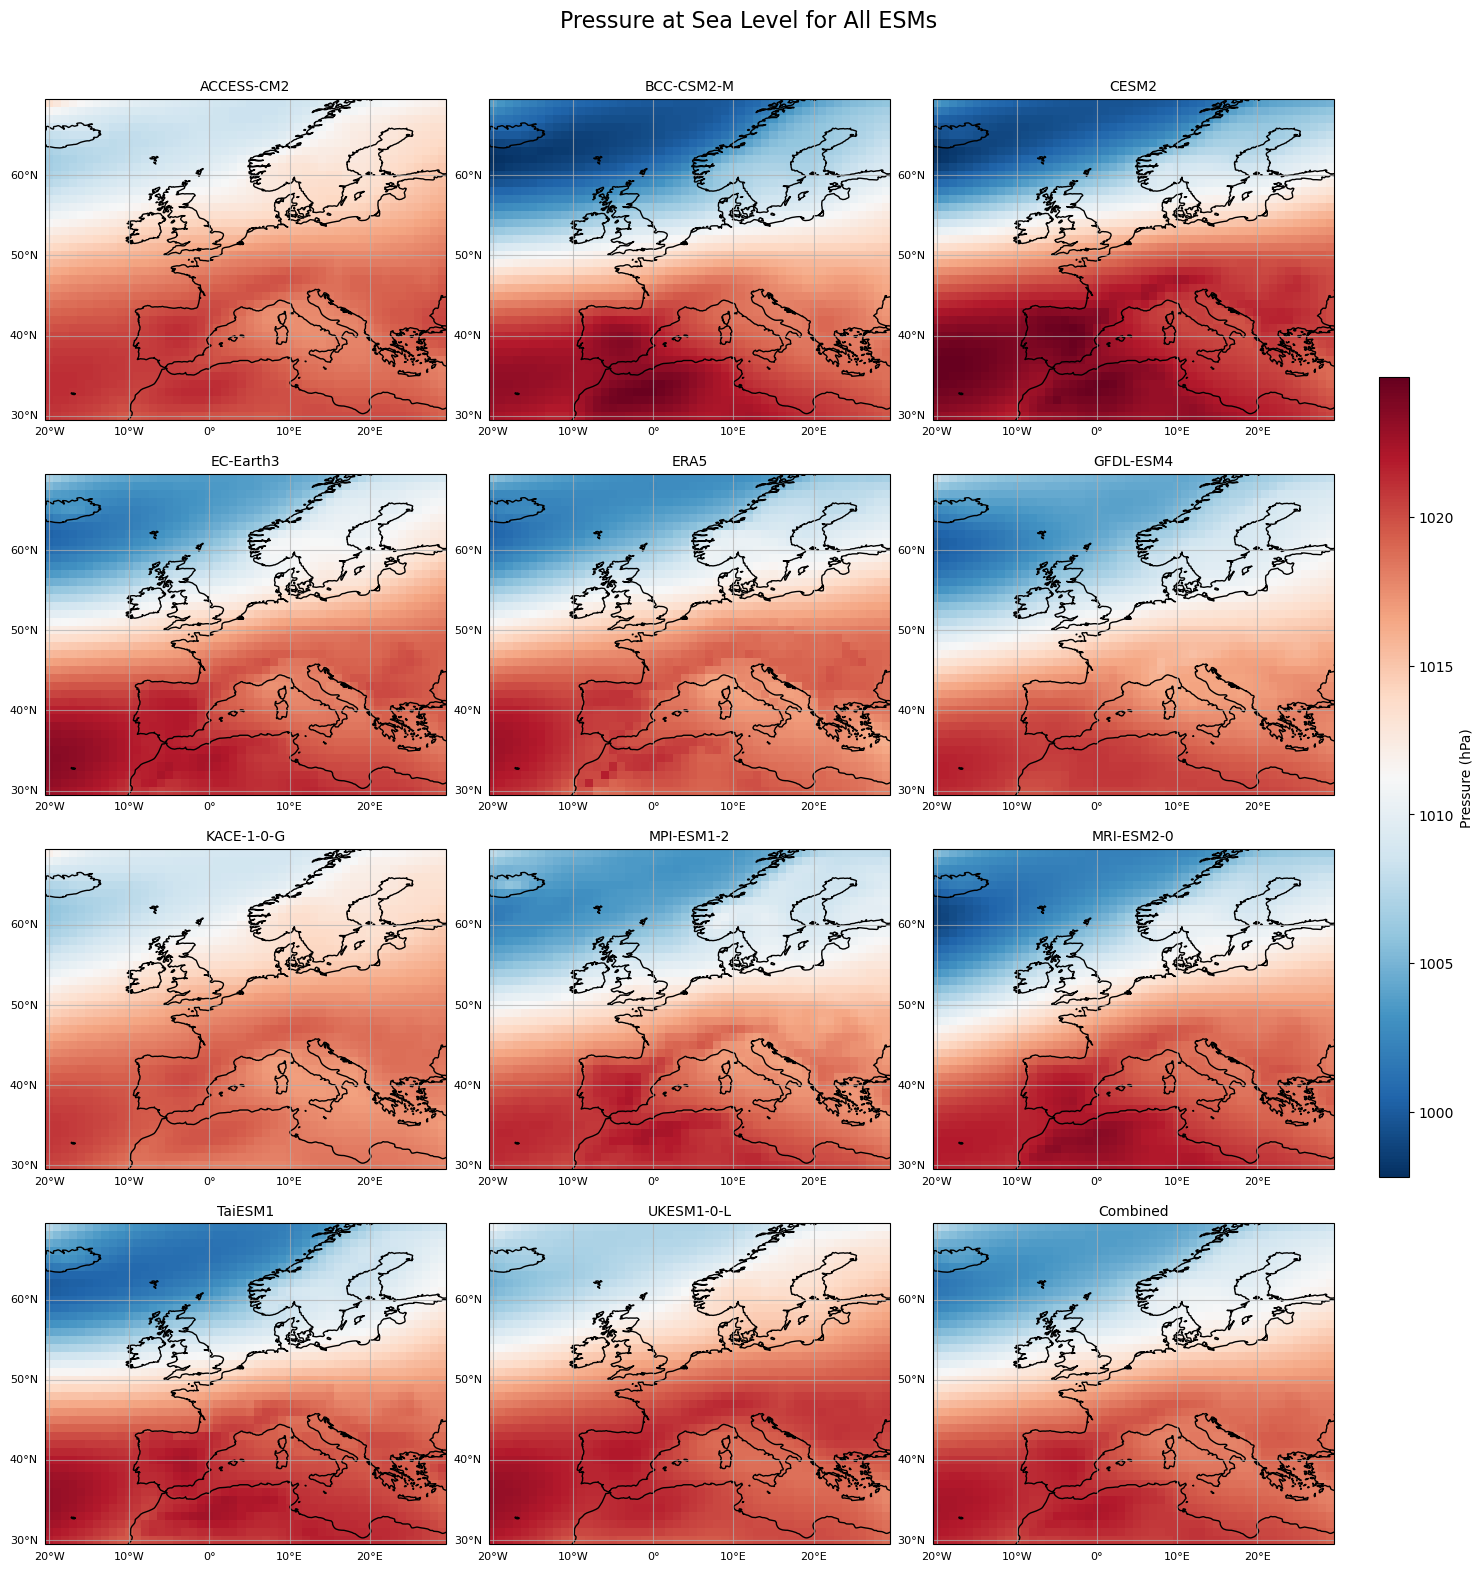

In [30]:
# Define vmin and vmax once
vmin = ts_combined['psl'].where(ts_combined['psl'] > 0).min() / 100
vmax = ts_combined['psl'].max() / 100

# Get ESM list and determine subplot layout
esm_list = ts_combined.ESM.values
n = len(esm_list)

# Choose rows/cols for subplot grid (auto-fit)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceil division

# Create a big figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes for easier indexing (handles both 1D/2D cases)
axes = axes.flatten()

for i, ESM in enumerate(esm_list):
    # print('ESM:', ESM)
    ds = ts_combined.sel(ESM=ESM)
    
    # Shift longitudes
    new_lon = ((ds['psl'].lon + 180) % 360) - 180
    da2 = ds['psl'].assign_coords(lon=new_lon) / 100

    # Plot on respective axis
    ax = axes[i]
    p = da2.plot(ax=ax, transform=ccrs.PlateCarree(),
                 cmap='RdBu_r', add_colorbar=False,
                 vmin=vmin, vmax=vmax)

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f'{ESM}', fontsize=10)

# Remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add one shared colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level for All ESMs', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title
plt.show()